In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

TICKER   = "ZAMAUSDT"
DATES    = ["2026-04-12", "2026-04-13", "2026-04-14"]
DATA_DIR = Path("../task_data") / TICKER

## 1. Lee-Ready — Algorithm

Combines Quote Rule (primary) with Tick Rule (fallback for at-the-quote trades).

| Condition | Label |
|---|---|
| price < midpoint | `True` — sell aggressor |
| price > midpoint | `False` — buy aggressor |
| price = midpoint, downtick | `True` — sell aggressor |
| price = midpoint, uptick | `False` — buy aggressor |
| price = midpoint, no prior tick | `None` — indeterminate |

In [2]:
all_data = {}
for date in DATES:
    ob = pd.read_parquet(DATA_DIR / f"{TICKER}_orderbook_{date}.parquet")
    tr = pd.read_parquet(DATA_DIR / f"{TICKER}_trades_{date}.parquet")
    mid = ((ob['ask0'] + ob['bid0']) / 2).rename('spread mid point')
    pm = pd.merge_asof(tr, mid.to_frame(), left_index=True, right_index=True, direction='backward')
    all_data[date] = {
        'pm': pm[['price', 'spread mid point', 'side']],
        'tick': np.sign(tr['price'].diff()).replace(0, np.nan).ffill(),
    }

{date: len(v['pm']) for date, v in all_data.items()}

{'2026-04-12': 31162, '2026-04-13': 32408, '2026-04-14': 578015}

## 2. Multi-Day Evaluation

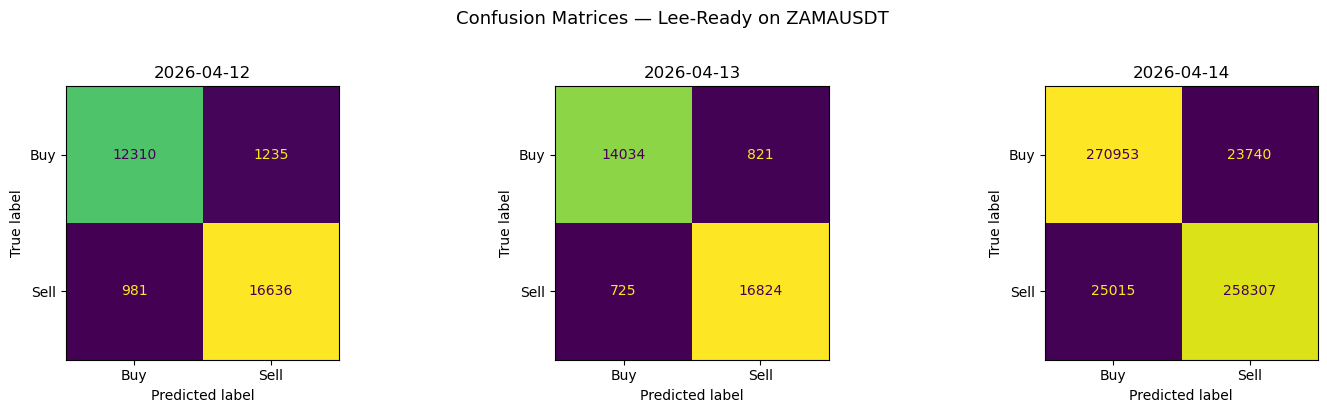

In [3]:
results = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, date in zip(axes, DATES):
    pm          = all_data[date]['pm']
    tick_filled = all_data[date]['tick']
    at_mid = pm['price'] == pm['spread mid point']
    trade_side = pd.Series(
        np.select(
            [pm['price'] < pm['spread mid point'],
             pm['price'] > pm['spread mid point'],
             at_mid & (tick_filled < 0),
             at_mid & (tick_filled > 0)],
            [True, False, True, False], default=None
        ),
        index=pm.index, name='predicted_trade_side'
    )
    final_df = pd.concat([pm, trade_side], axis=1).dropna()
    y_true = final_df['side'].astype(bool)
    y_pred  = final_df['predicted_trade_side'].astype(bool)
    results[date] = (y_true, y_pred, len(pm) - len(final_df))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=['Buy', 'Sell'], colorbar=False, ax=ax
    )
    ax.set_title(date)

fig.suptitle(f'Confusion Matrices — Lee-Ready on {TICKER}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Per-Day Classification Reports

In [4]:
for date, (y_true, y_pred, indet) in results.items():
    print(f"\n=== {date}  (indeterminate: {indet}) ===")
    print(classification_report(y_true, y_pred, target_names=['Buy (False)', 'Sell (True)']))


=== 2026-04-12  (indeterminate: 0) ===
              precision    recall  f1-score   support

 Buy (False)       0.93      0.91      0.92     13545
 Sell (True)       0.93      0.94      0.94     17617

    accuracy                           0.93     31162
   macro avg       0.93      0.93      0.93     31162
weighted avg       0.93      0.93      0.93     31162


=== 2026-04-13  (indeterminate: 4) ===
              precision    recall  f1-score   support

 Buy (False)       0.95      0.94      0.95     14855
 Sell (True)       0.95      0.96      0.96     17549

    accuracy                           0.95     32404
   macro avg       0.95      0.95      0.95     32404
weighted avg       0.95      0.95      0.95     32404


=== 2026-04-14  (indeterminate: 0) ===
              precision    recall  f1-score   support

 Buy (False)       0.92      0.92      0.92    294693
 Sell (True)       0.92      0.91      0.91    283322

    accuracy                           0.92    578015
   macro

## 4. Summary

In [5]:
records = []
for date, (y_true, y_pred, indet) in results.items():
    r = classification_report(y_true, y_pred, target_names=['Buy', 'Sell'], output_dict=True)
    records.append({
        'Date': date, 'Samples': len(y_true), 'Indeterminate': indet,
        'Accuracy': r['accuracy'],
        'Buy F1': r['Buy']['f1-score'],
        'Sell F1': r['Sell']['f1-score'],
        'Macro F1': r['macro avg']['f1-score'],
    })

pd.DataFrame(records).set_index('Date').style \
    .format({'Accuracy': '{:.4f}', 'Buy F1': '{:.4f}', 'Sell F1': '{:.4f}', 'Macro F1': '{:.4f}'}) \
    .highlight_max(subset=['Accuracy', 'Buy F1', 'Sell F1', 'Macro F1'], color='lightgreen')

,Samples,Indeterminate,Accuracy,Buy F1,Sell F1,Macro F1
Date,,,,,,
2026-04-12,31162,0,0.9289,0.9174,0.9376,0.9275
2026-04-13,32404,4,0.9523,0.9478,0.9561,0.9519
2026-04-14,578015,0,0.9157,0.9175,0.9138,0.9156
